# NileRed BZ Reaction Twin — synthesis and Rowan gate

A clean research companion for [Recreating one of the weirdest reactions](https://www.youtube.com/watch?v=LL3kVtc-4vY).

The project has two layers: normalized kinetics now, and a Rowan-managed molecular mechanism path only after a specific elementary step, mapped 3-D endpoints, and an explicit credit budget are approved. This is not a wet-lab recipe and does not reconstruct the full BZ network with one molecular calculation.

In [1]:
from pathlib import Path
import importlib.metadata
import numpy as np
import matplotlib.pyplot as plt
from nilered_twin import OregonatorParameters, SpatialOregonatorParameters, default_synthesis_plan, simulate_oregonator, simulate_oregonator_1d

OUTPUTS = Path("../outputs")
OUTPUTS.mkdir(exist_ok=True)
print("Outputs:", OUTPUTS.resolve())
print("Plan stages:", len(default_synthesis_plan()))

Outputs: /root/sessions/204115_networking-venues-for-investors/creator-repos/nilered-bz-reaction-twin/outputs
Plan stages: 6


In [2]:
print("SYNTHESIS PLAN")
for stage in default_synthesis_plan():
    print(f"{stage.stage}: {stage.objective} | route={stage.route} | gate={stage.acceptance_gate}")

SYNTHESIS PLAN
01_scope: Define the visible oscillatory phenomenon and the question to test. | route=local | gate=Question, observable, and units are explicit.
02_kinetics: Fit or stress-test the dimensionless well-mixed and spatial Oregonator layers. | route=local | gate=Solver success, peak detection, and parameter sensitivity are reported.
03_structure_gate: Select a creator- and chemist-approved elementary step for molecular study. | route=human review | gate=Atom ordering matches; charge, spin, geometry source, and scope are recorded.
04_rowan_path: Characterize the selected elementary step with bounded managed molecular modeling. | route=Rowan | gate=Submission is authorized; TS is checked with frequencies and, when appropriate, IRC.
05_observation_bridge: Compare model phase, period, and waveform shape to an anonymized intensity trace. | route=local + Rowan results | gate=Timebase, preprocessing, and residuals are visible.
06_creator_review: Return a concise failure-aware summar

In [3]:
kinetics = OregonatorParameters(epsilon=0.01, q=0.002, f=1.4)
well_mixed = simulate_oregonator(kinetics)
spatial_params = SpatialOregonatorParameters(kinetics=kinetics, domain_length=60.0, n_points=60, t_end=80.0, n_samples=401)
spatial = simulate_oregonator_1d(spatial_params)
print("MODEL VALIDATION")
print("method: LSODA for 0-D; BDF with sparse Jacobian pattern for 1-D")
print("units: dimensionless time, state variables, and position")
print(f"epsilon={kinetics.epsilon}, q={kinetics.q}, f={kinetics.f}")
print(f"well-mixed peaks={well_mixed['peak_count']}; period={well_mixed['mean_period']:.6f}; std={well_mixed['period_std']:.6f}")
print(f"spatial solver success={spatial['solver_success']}; max x-field SD={spatial['max_spatial_std']:.6f}; final SD={spatial['final_spatial_std']:.6f}")

MODEL VALIDATION
method: LSODA for 0-D; BDF with sparse Jacobian pattern for 1-D
units: dimensionless time, state variables, and position
epsilon=0.01, q=0.002, f=1.4
well-mixed peaks=14; period=10.534615; std=0.004985
spatial solver success=True; max x-field SD=0.214174; final SD=0.000006


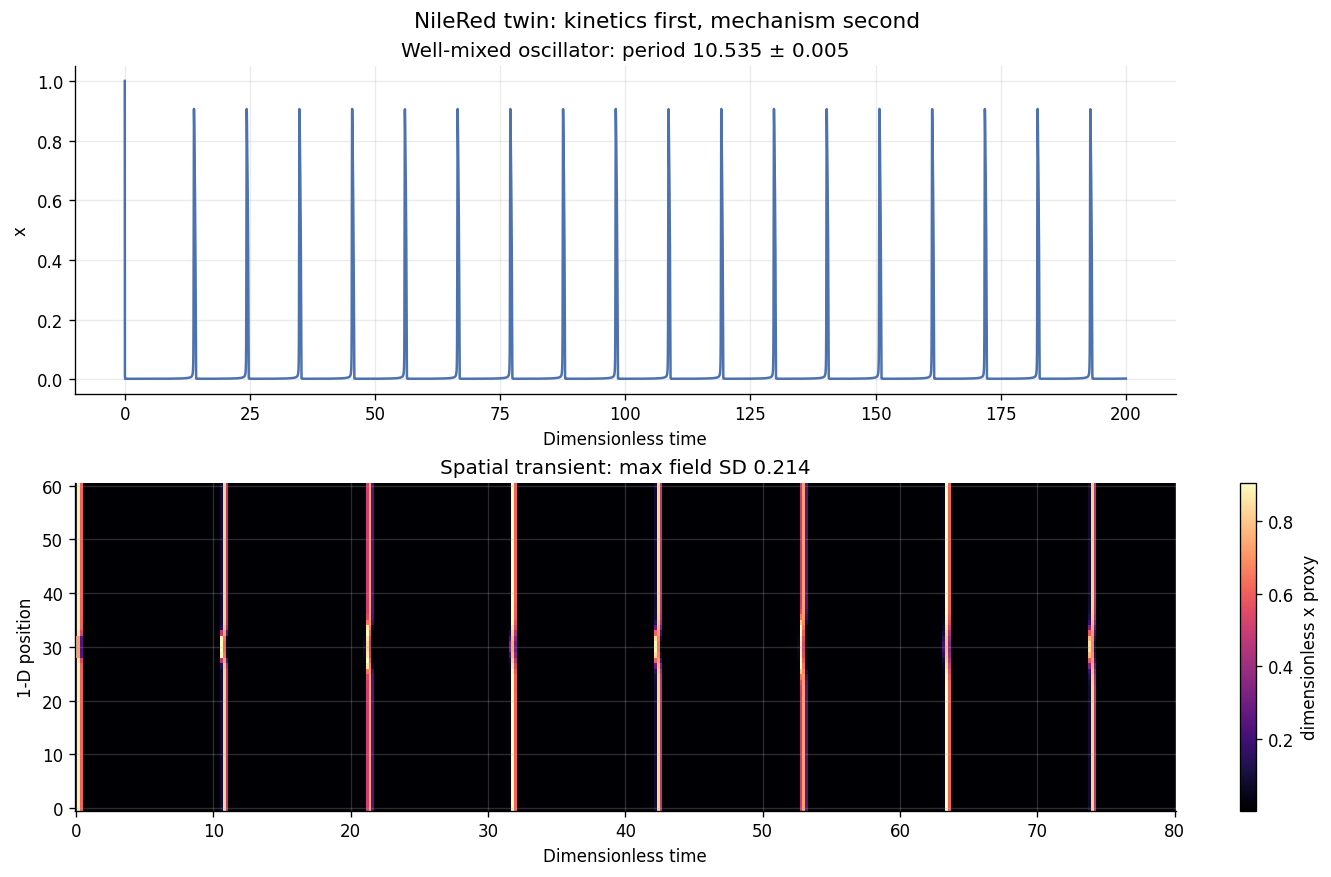

Saved ../outputs/synthesis_review.png


In [4]:
state = spatial["state"]
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})
fig, axes = plt.subplots(2, 1, figsize=(11, 7.2), constrained_layout=True)
axes[0].plot(well_mixed["time"], well_mixed["state"][0], color="#4c72b0")
axes[0].set_xlabel("Dimensionless time"); axes[0].set_ylabel("x"); axes[0].set_title(f"Well-mixed oscillator: period {well_mixed['mean_period']:.3f} ± {well_mixed['period_std']:.3f}")
heat = axes[1].pcolormesh(spatial["time"], spatial["position"], state[0], shading="auto", cmap="magma")
axes[1].set_xlabel("Dimensionless time"); axes[1].set_ylabel("1-D position"); axes[1].set_title(f"Spatial transient: max field SD {spatial['max_spatial_std']:.3f}")
fig.colorbar(heat, ax=axes[1], label="dimensionless x proxy")
fig.suptitle("NileRed twin: kinetics first, mechanism second", fontsize=13)
fig.savefig(OUTPUTS / "synthesis_review.png", bbox_inches="tight")
plt.show()
print("Saved", OUTPUTS / "synthesis_review.png")

In [5]:
try:
    print("ROWAN PREFLIGHT SUMMARY")
    print("rowan-python:", importlib.metadata.version("rowan-python"))
    import rowan
    print("descriptors exposed:", hasattr(rowan, "submit_descriptors_workflow"))
    print("basic calculation exposed:", hasattr(rowan, "submit_basic_calculation_workflow"))
    print("double-ended TS exposed:", hasattr(rowan, "submit_double_ended_ts_search_workflow"))
    print("submission status: NOT SUBMITTED")
    print("reason: approved structures and budget are required")
except Exception as exc:
    print("Rowan preflight unavailable:", type(exc).__name__, str(exc))

ROWAN PREFLIGHT SUMMARY
rowan-python: 3.1.8


descriptors exposed: True
basic calculation exposed: True
double-ended TS exposed: True
submission status: NOT SUBMITTED
reason: approved structures and budget are required


## Next gate

A creator or chemist chooses one elementary transformation and supplies provenance-backed, atom-order-matched 3-D endpoints. Only then can the Rowan path be evaluated. Frequencies and, if justified, IRC/connectivity checks are acceptance criteria; a TS search alone is not proof.